<a href="https://colab.research.google.com/github/mbenedicto99/CrewAI_LAB01/blob/main/notebook_gnn_rca_observabilidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulação acadêmica de RCA em Observabilidade com GNN

Este notebook apresenta uma implementação experimental e reproduzível de *root cause analysis* em um ambiente sintético de microservices. A proposta é transformar sinais de observabilidade, como métricas, logs, traces e eventos operacionais, em um grafo multimodal no qual uma *Graph Neural Network* estima um ranking de candidatos à causa raiz.

A motivação central é metodológica. Em sistemas distribuídos, uma falha local pode produzir sintomas em serviços vizinhos, componentes consumidores, filas, bancos de dados e rotas de negócio. Por isso, tratar cada serviço de forma isolada tende a confundir sintoma com origem. A formulação em grafo representa explicitamente dependências e caminhos de propagação. O experimento não pretende substituir dados reais de produção, mas oferecer um protótipo controlado para testar hipóteses, comparar uma GNN com um baseline sem topologia explícita e documentar as escolhas matemáticas de cada fase.

O notebook segue a hipótese de que, se um incidente se propaga por relações de dependência, a estrutura do grafo deve carregar informação útil para RCA. Essa hipótese será tratada como verificável, não como pressuposto. Por esse motivo, o modelo GCN é comparado com um MLP que usa os mesmos atributos dos nós, mas não recebe a matriz de adjacência.

## 1. Formulação do problema

Considere um sistema distribuído composto por um conjunto de entidades operacionais \(V\), como serviços, bancos de dados, filas e gateways. As relações de dependência são representadas por arestas \(E\), formando um grafo \(G=(V,E,A)\), em que \(A\) é a matriz de adjacência. Para cada nó \(v\in V\) e instante \(t\), são observados sinais externos de telemetria, agregados em um vetor multimodal:

\[
x_v(t) = [m_v(t),\; l_v(t),\; r_v(t),\; e_v(t)]
\]

Nesse vetor, \(m_v(t)\) representa métricas, \(l_v(t)\) representa logs ou atributos derivados de logs, \(r_v(t)\) representa traces e \(e_v(t)\) representa eventos operacionais. A tarefa de RCA é estimar, para cada incidente \(i\), a probabilidade de cada nó ser a causa raiz:

\[
p(v\mid G_i, X_i) = \operatorname{softmax}(f_\theta(G_i, X_i))_v
\]

O resultado operacional é um ranking \(R_i\), ordenado por \(p(v\mid G_i, X_i)\), que deve posicionar a causa real nas primeiras posições. As métricas usadas serão *Top-k Accuracy*, *Mean Reciprocal Rank* e posição média da causa raiz.

## 2. Bases conceituais e modelos matemáticos usados

A simulação combina cinco famílias de modelos. O primeiro é o modelo de espaço de estados, usado como analogia formal para observabilidade: um estado interno latente \(x(t)\) gera saídas observáveis \(y(t)\). A formulação simplificada é:

\[
x(t+1)=F x(t)+B u(t)+\epsilon_t, \qquad y(t)=C x(t)+\nu_t
\]

Neste notebook, o estado latente representa degradação interna de cada serviço, enquanto a saída observável corresponde a métricas, logs e traces. O segundo modelo é a teoria de grafos, em que dependências entre serviços são codificadas por \(A\). O terceiro é a detecção estatística de anomalias por *z-score*, usada para converter telemetria bruta em desvio padronizado:

\[
z_v(t)=\frac{x_v(t)-\mu_v}{\sigma_v+\varepsilon}
\]

O quarto é um modelo de difusão em grafo. Dado um vetor de anomalia local \(s\), a difusão estima como a suspeição se espalha pela topologia:

\[
d = \sum_{k=0}^{K}\alpha_k P^k s
\]

em que \(P\) é uma matriz de transição derivada da topologia e \(\alpha_k\) controla a influência de vizinhos a diferentes distâncias. O quinto modelo é uma GCN, que atualiza representações dos nós por agregação de vizinhança:

\[
H^{(\ell+1)}=\sigma(\hat{A}H^{(\ell)}W^{(\ell)})
\]

com \(\hat{A}=D^{-1/2}(A+I)D^{-1/2}\). A saída final é um escore por nó, convertido em distribuição de probabilidade por *softmax*.

## 3. Ambiente de execução

A implementação usa bibliotecas comuns do ecossistema Python. A GNN foi implementada diretamente em PyTorch, sem PyTorch Geometric, para que as equações fiquem visíveis e auditáveis. A instalação abaixo é suficiente em um ambiente local Ubuntu com Python 3.10 ou superior.

In [1]:
# Execute esta célula apenas se seu ambiente ainda não tiver as bibliotecas instaladas.
# Em um notebook local, remova o comentário da linha abaixo.
# %pip install numpy pandas matplotlib networkx scikit-learn torch

In [2]:
import math
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
except Exception as exc:
    TORCH_AVAILABLE = False
    print("PyTorch não está disponível neste ambiente. Instale com: pip install torch")
    print(exc)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

## 4. Construção do grafo de microservices

O grafo abaixo representa uma arquitetura sintética, porém compatível com padrões comuns em ambientes distribuídos. O gateway chama serviços de negócio, os serviços dependem de filas, bancos de dados e componentes compartilhados. As arestas possuem direção de chamada, mas o treinamento usa uma matriz simetrizada para capturar propagação de sintomas nos dois sentidos: uma dependência degradada pode afetar seus consumidores, e um consumidor anômalo pode apontar para uma dependência compartilhada.

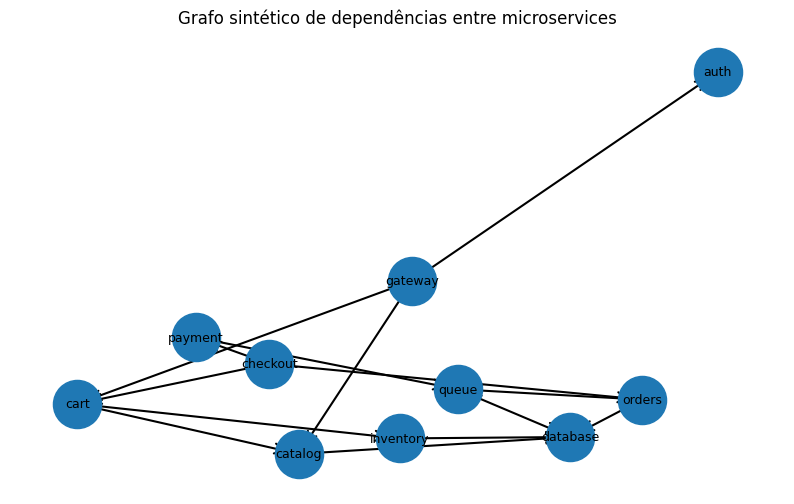

In [3]:
services = [
    "gateway", "auth", "catalog", "cart", "checkout",
    "payment", "orders", "inventory", "queue", "database"
]

edges = [
    ("gateway", "auth"),
    ("gateway", "catalog"),
    ("gateway", "cart"),
    ("cart", "catalog"),
    ("cart", "inventory"),
    ("checkout", "cart"),
    ("checkout", "payment"),
    ("checkout", "orders"),
    ("payment", "queue"),
    ("orders", "queue"),
    ("orders", "database"),
    ("catalog", "database"),
    ("inventory", "database"),
    ("queue", "database"),
]

G = nx.DiGraph()
G.add_nodes_from(services)
G.add_edges_from(edges)
node_to_idx = {name: i for i, name in enumerate(services)}
idx_to_node = {i: name for name, i in node_to_idx.items()}
N = len(services)

A_directed = nx.to_numpy_array(G, nodelist=services, dtype=float)
A_sym = ((A_directed + A_directed.T) > 0).astype(float)

# Matriz de transição para difusão. Cada linha soma 1 quando há vizinhos.
row_sum = A_sym.sum(axis=1, keepdims=True)
P = np.divide(A_sym, row_sum, out=np.zeros_like(A_sym), where=row_sum != 0)

# Matriz normalizada usada na GCN: D^(-1/2)(A+I)D^(-1/2)
A_tilde = A_sym + np.eye(N)
deg = A_tilde.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(deg))
A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

pos = nx.spring_layout(G, seed=SEED)
plt.figure(figsize=(10, 6))
nx.draw_networkx_nodes(G, pos, node_size=1200)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=18, width=1.5)
nx.draw_networkx_labels(G, pos, font_size=9)
plt.title("Grafo sintético de dependências entre microservices")
plt.axis("off")
plt.show()

## 5. Simulação do estado latente de degradação

A telemetria observada é gerada a partir de um estado interno não diretamente visível. Esse desenho reproduz a ideia de que observabilidade não é apenas coleta de dados, mas inferência sobre um estado interno a partir de sinais externos. Para cada incidente, um nó recebe um choque inicial de falha. A degradação se propaga pela topologia segundo uma dinâmica linear com ruído:

\[
g(t+1)=\rho g(t)+\beta P^\top g(t)+q_c(t)+\epsilon_t
\]

O termo \(g(t)\) mede a severidade latente por serviço. O termo \(q_c(t)\) representa a falha injetada na causa raiz \(c\). A matriz \(P^\top\) faz a degradação caminhar pelas relações do grafo. Essa dinâmica é propositalmente simples para manter interpretabilidade experimental.

In [4]:
@dataclass
class IncidentConfig:
    T: int = 80
    t0: int = 35
    rho: float = 0.70
    beta: float = 0.22
    shock_strength: float = 2.2
    noise_std: float = 0.035

base_latency = np.array([42, 18, 25, 30, 35, 45, 38, 28, 20, 32], dtype=float)
base_error = np.array([0.008, 0.004, 0.005, 0.006, 0.007, 0.010, 0.007, 0.006, 0.004, 0.006])
base_cpu = np.array([45, 30, 35, 38, 42, 48, 40, 37, 28, 52], dtype=float)
base_mem = np.array([55, 35, 42, 45, 48, 50, 46, 43, 30, 60], dtype=float)
base_rps = np.array([900, 320, 420, 380, 260, 210, 230, 240, 180, 360], dtype=float)

failure_profiles = {
    "latency": np.array([1.30, 0.25, 0.30, 0.20, 0.25, 0.10]),
    "error":   np.array([0.55, 1.20, 0.20, 0.35, 0.20, 0.10]),
    "cpu":     np.array([0.35, 0.15, 1.15, 0.25, 0.20, 0.10]),
    "memory":  np.array([0.25, 0.10, 0.25, 1.10, 0.20, 0.10]),
    "queue":   np.array([0.70, 0.40, 0.25, 0.25, 1.30, 0.20]),
    "deploy":  np.array([0.45, 0.55, 0.25, 0.20, 0.20, 1.20]),
}
profile_names = list(failure_profiles.keys())

# Dimensões do vetor de perfil: latency, error, cpu, memory, trace, config/deploy.

def simulate_latent_degradation(root_idx: int, cfg: IncidentConfig) -> np.ndarray:
    g = np.zeros((cfg.T, N), dtype=float)
    for t in range(1, cfg.T):
        seasonal = 0.015 * np.sin(2 * np.pi * t / 24)
        shock = np.zeros(N)
        if t >= cfg.t0:
            # Falha persistente com leve decaimento para manter o cenário realista.
            shock[root_idx] = cfg.shock_strength * math.exp(-0.012 * (t - cfg.t0))
        propagation = cfg.beta * (P.T @ g[t - 1])
        noise = np.random.normal(0, cfg.noise_std, size=N)
        g[t] = np.maximum(0, cfg.rho * g[t - 1] + propagation + shock + seasonal + noise)
    return g

## 6. Geração de métricas, logs, traces e eventos

A partir da degradação latente, o notebook gera quatro grupos de sinais. Métricas capturam latência, erro, CPU, memória e vazão. Logs são representados por contagens de padrões textuais agregados, como mensagens de timeout, exceção e configuração. Traces são representados por duração média, taxa de spans com erro e profundidade aproximada da requisição. Eventos operacionais sinalizam mudanças, como deploy, com maior probabilidade quando o perfil de falha é do tipo configuração.

Essa etapa simula um cenário em que a informação relevante não está concentrada em um único sinal. A causa raiz pode aparecer como degradação local, mas seus sintomas podem se espalhar por serviços consumidores ou dependências compartilhadas.

In [5]:
def generate_telemetry(g: np.ndarray, root_idx: int, profile_name: str, cfg: IncidentConfig) -> Dict[str, np.ndarray]:
    T = cfg.T
    profile = failure_profiles[profile_name]
    time = np.arange(T)
    daily = 1.0 + 0.08 * np.sin(2 * np.pi * time / 24)

    g_effect = g
    latency = base_latency[None, :] * daily[:, None] * (1 + profile[0] * g_effect) + np.random.normal(0, 2.0, (T, N))
    error_rate = np.clip(base_error[None, :] + 0.025 * profile[1] * g_effect + np.random.normal(0, 0.002, (T, N)), 0, 1)
    cpu = np.clip(base_cpu[None, :] * (1 + 0.20 * profile[2] * g_effect) + np.random.normal(0, 3.0, (T, N)), 0, 100)
    memory = np.clip(base_mem[None, :] * (1 + 0.16 * profile[3] * g_effect) + np.random.normal(0, 2.0, (T, N)), 0, 100)
    throughput = np.maximum(1, base_rps[None, :] * daily[:, None] * (1 - 0.10 * g_effect) + np.random.normal(0, 20.0, (T, N)))

    trace_duration = latency * (1 + 0.15 * profile[4] * g_effect) + np.random.normal(0, 2.0, (T, N))
    trace_error_ratio = np.clip(error_rate * (1 + 0.60 * profile[4] * g_effect), 0, 1)
    trace_depth = np.tile(np.array([3, 1, 2, 3, 4, 2, 3, 2, 1, 1], dtype=float), (T, 1))
    trace_depth += np.random.normal(0, 0.2, (T, N))

    # Logs sintéticos agregados por janela: timeout, exception, queue_wait, db_error, config_change.
    log_timeout = np.random.poisson(1.5 + 3.5 * profile[0] * g_effect)
    log_exception = np.random.poisson(1.0 + 4.2 * profile[1] * g_effect)
    log_queue = np.random.poisson(0.8 + 4.0 * profile[4] * g_effect)
    log_db = np.random.poisson(0.8 + 3.5 * g_effect * np.isin(np.arange(N), [node_to_idx["database"], node_to_idx["orders"], node_to_idx["catalog"]])[None, :])
    log_config = np.random.poisson(0.3 + 3.2 * profile[5] * g_effect)

    deploy_event = np.zeros((T, N), dtype=float)
    if profile_name == "deploy":
        deploy_event[cfg.t0 - 2:cfg.t0 + 3, root_idx] = 1.0
    else:
        random_node = np.random.randint(0, N)
        if np.random.rand() < 0.15:
            deploy_event[cfg.t0 - 3:cfg.t0 - 1, random_node] = 1.0

    return {
        "latency": latency,
        "error_rate": error_rate,
        "cpu": cpu,
        "memory": memory,
        "throughput": throughput,
        "trace_duration": trace_duration,
        "trace_error_ratio": trace_error_ratio,
        "trace_depth": trace_depth,
        "log_timeout": log_timeout.astype(float),
        "log_exception": log_exception.astype(float),
        "log_queue": log_queue.astype(float),
        "log_db": log_db.astype(float),
        "log_config": log_config.astype(float),
        "deploy_event": deploy_event,
        "latent_degradation": g,
    }

## 7. Extração de atributos por nó

Para cada incidente, a telemetria é dividida em uma janela de referência anterior ao incidente e uma janela de investigação posterior. O objetivo é converter séries temporais em atributos comparáveis por nó. Para cada sinal, calcula-se o desvio padronizado em relação à linha de base do próprio serviço. Em seguida, são extraídas estatísticas de máximo, média ou mínimo, conforme a natureza do sinal.

A anomalia local é representada por uma combinação ponderada de sinais padronizados:

\[
s_v = \sigma(w^\top \phi_v + b)
\]

em que \(\phi_v\) é o vetor agregado por nó. Esse escore é útil, mas insuficiente para RCA, pois um serviço impactado pode ter anomalia maior que a causa real. Por isso, o notebook calcula uma variável de difusão topológica e a concatena aos atributos do nó.

In [6]:
def zscore_against_baseline(series: np.ndarray, t0: int) -> np.ndarray:
    baseline = series[:t0]
    mu = baseline.mean(axis=0, keepdims=True)
    sigma = baseline.std(axis=0, keepdims=True) + 1e-6
    return (series - mu) / sigma


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def diffuse_scores(local_score: np.ndarray, P: np.ndarray, alphas=(0.55, 0.30, 0.15)) -> np.ndarray:
    result = np.zeros_like(local_score, dtype=float)
    P_power = np.eye(P.shape[0])
    for alpha in alphas:
        result += alpha * (P_power @ local_score)
        P_power = P_power @ P
    return result


def extract_node_features(telemetry: Dict[str, np.ndarray], cfg: IncidentConfig) -> Tuple[np.ndarray, List[str], np.ndarray]:
    t0 = cfg.t0
    win = slice(t0, None)

    z_latency = zscore_against_baseline(telemetry["latency"], t0)
    z_error = zscore_against_baseline(telemetry["error_rate"], t0)
    z_cpu = zscore_against_baseline(telemetry["cpu"], t0)
    z_memory = zscore_against_baseline(telemetry["memory"], t0)
    z_throughput = zscore_against_baseline(telemetry["throughput"], t0)
    z_trace_duration = zscore_against_baseline(telemetry["trace_duration"], t0)
    z_trace_error = zscore_against_baseline(telemetry["trace_error_ratio"], t0)
    z_log_timeout = zscore_against_baseline(telemetry["log_timeout"], t0)
    z_log_exception = zscore_against_baseline(telemetry["log_exception"], t0)
    z_log_queue = zscore_against_baseline(telemetry["log_queue"], t0)
    z_log_db = zscore_against_baseline(telemetry["log_db"], t0)
    z_log_config = zscore_against_baseline(telemetry["log_config"], t0)

    features = np.column_stack([
        z_latency[win].max(axis=0),
        z_error[win].max(axis=0),
        z_cpu[win].max(axis=0),
        z_memory[win].max(axis=0),
        -z_throughput[win].min(axis=0),
        z_trace_duration[win].max(axis=0),
        z_trace_error[win].max(axis=0),
        z_log_timeout[win].max(axis=0),
        z_log_exception[win].max(axis=0),
        z_log_queue[win].max(axis=0),
        z_log_db[win].max(axis=0),
        z_log_config[win].max(axis=0),
        telemetry["deploy_event"][win].max(axis=0),
    ])

    feature_names = [
        "latency_z_max", "error_z_max", "cpu_z_max", "memory_z_max", "throughput_drop_z",
        "trace_duration_z_max", "trace_error_z_max", "log_timeout_z_max", "log_exception_z_max",
        "log_queue_z_max", "log_db_z_max", "log_config_z_max", "deploy_event"
    ]

    # Peso heurístico apenas para gerar anomalia local inicial; o treinamento aprende sua própria ponderação.
    w = np.array([0.16, 0.18, 0.10, 0.08, 0.08, 0.12, 0.12, 0.06, 0.05, 0.03, 0.03, 0.04, 0.10])
    local_score = sigmoid(features @ w - 1.0)
    diffusion_score = diffuse_scores(local_score, P).reshape(-1, 1)

    features = np.column_stack([features, local_score.reshape(-1, 1), diffusion_score])
    feature_names += ["local_anomaly_score", "graph_diffusion_score"]
    return features.astype(np.float32), feature_names, local_score

### 8. Demonstração de Meta-Caminhos para Grafos Heterogêneos (Exemplo Simplificado)

Meta-caminhos são sequências de tipos de nós e arestas que descrevem uma relação composta em um grafo heterogêneo. Embora seu grafo atual seja tecnicamente homogêneo (todos os nós são serviços e todas as arestas são dependências), podemos simular tipos específicos de relações considerando nós como 'database' e 'queue' como categorias distintas dentro do ecossistema de serviços.

Vamos definir dois meta-caminhos de exemplo e extrair features binárias para cada serviço, indicando se ele participa do início desses meta-caminhos:

1.  **Serviço -> Database**: Um serviço que tem uma dependência direta (ou próxima) com o nó `database`.
2.  **Serviço -> Queue -> Database**: Um serviço que se conecta a um `database` através de uma `queue`.

Estas features poderiam ser incorporadas no vetor de atributos `X_node` de cada serviço.

In [7]:
# Identificar os nós 'database' e 'queue' pelos seus nomes e índices
database_idx = node_to_idx["database"]
database_name = idx_to_node[database_idx]

queue_idx = node_to_idx["queue"]
queue_name = idx_to_node[queue_idx]

# Inicializar um array para armazenar as features de meta-caminho para cada serviço
# meta_path_features[i, 0] para 'Service -> Database'
# meta_path_features[i, 1] para 'Service -> Queue -> Database'
meta_path_features = np.zeros((N, 2), dtype=float)

for i, service_name in enumerate(services):
    # Feature 1: Serviço -> Database
    # Verifica se há uma aresta direta do serviço para o 'database'
    # (Isto pode ser estendido para verificar paths mais longos)
    if (service_name, database_name) in G.edges():
        meta_path_features[i, 0] = 1.0

    # Feature 2: Serviço -> Queue -> Database
    # Verifica se o serviço está conectado ao 'database' via 'queue'
    # Ou seja, se existe uma aresta (serviço -> queue) E (queue -> database)
    if (service_name, queue_name) in G.edges() and (queue_name, database_name) in G.edges():
        meta_path_features[i, 1] = 1.0

# Criar um DataFrame para visualizar as novas features
meta_path_feature_names = ["meta_path_svc_to_db", "meta_path_svc_to_q_to_db"]
meta_path_df = pd.DataFrame(meta_path_features, columns=meta_path_feature_names, index=services)

print("Features de Meta-Caminhos para cada serviço:")
display(meta_path_df)

# Explicação de como integrar:
# Em uma implementação completa, estas features seriam concatenadas ao 'X_node'
# dentro da função extract_node_features ou usadas para definir diferentes
# tipos de agregação na GCN (como em uma RGCN).

Features de Meta-Caminhos para cada serviço:


,meta_path_svc_to_db,meta_path_svc_to_q_to_db
gateway,0.0,0.0
auth,0.0,0.0
catalog,1.0,0.0
cart,0.0,0.0
checkout,0.0,0.0
payment,0.0,1.0
orders,1.0,1.0
inventory,1.0,0.0
queue,1.0,0.0
database,0.0,0.0


## 9. Construção do dataset sintético

Cada amostra do dataset representa um incidente completo. O rótulo é o índice do nó que recebeu o choque inicial de falha. O dataset é balanceado de maneira aproximada, pois a causa raiz é sorteada entre os serviços e o tipo de falha é sorteado entre perfis operacionais distintos. Essa escolha reduz o risco de o modelo aprender apenas uma classe dominante.

In [8]:
def simulate_incident(root_idx: int = None, profile_name: str = None, cfg: IncidentConfig = IncidentConfig()):
    if root_idx is None:
        root_idx = np.random.randint(0, N)
    if profile_name is None:
        profile_name = random.choice(profile_names)
    g = simulate_latent_degradation(root_idx, cfg)
    telemetry = generate_telemetry(g, root_idx, profile_name, cfg)
    X_node, feature_names, local_score = extract_node_features(telemetry, cfg)
    return X_node, root_idx, profile_name, telemetry, local_score, feature_names


def build_dataset(n_incidents: int = 2000, cfg: IncidentConfig = IncidentConfig()):
    X_list, y_list, profiles = [], [], []
    dataset_feature_names = None
    for _ in range(n_incidents):
        root = np.random.randint(0, N)
        profile = random.choice(profile_names)
        X_node, y_val, profile_val, _, _, current_feature_names = simulate_incident(root, profile, cfg)
        X_list.append(X_node)
        y_list.append(y_val)
        profiles.append(profile_val)
        if dataset_feature_names is None:
            dataset_feature_names = current_feature_names
    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=np.int64)
    return X, y, profiles, dataset_feature_names

cfg = IncidentConfig()
X, y, profiles, feature_names = build_dataset(n_incidents=2000, cfg=cfg)
print("Formato de X:", X.shape, "  Amostras, nós, atributos")
print("Formato de y:", y.shape)
print("Atributos:", feature_names)

class_distribution = pd.Series([idx_to_node[i] for i in y]).value_counts().sort_index()
display(class_distribution.to_frame("incidentes"))

Formato de X: (2000, 10, 15)   Amostras, nós, atributos
Formato de y: (2000,)
Atributos: ['latency_z_max', 'error_z_max', 'cpu_z_max', 'memory_z_max', 'throughput_drop_z', 'trace_duration_z_max', 'trace_error_z_max', 'log_timeout_z_max', 'log_exception_z_max', 'log_queue_z_max', 'log_db_z_max', 'log_config_z_max', 'deploy_event', 'local_anomaly_score', 'graph_diffusion_score']


,incidentes
auth,214
cart,191
catalog,204
checkout,179
database,195
gateway,182
inventory,198
orders,223
payment,200
queue,214


## 10. Exemplo visual de um incidente

Antes do treinamento, é útil inspecionar um caso individual. O gráfico temporal mostra como a degradação latente da causa raiz se propaga. A tabela exibe os serviços com maior anomalia local e maior difusão topológica. Em cenários reais, essa fase corresponderia à exploração inicial feita por SREs durante a investigação.

Causa raiz simulada: payment
Perfil de falha: error


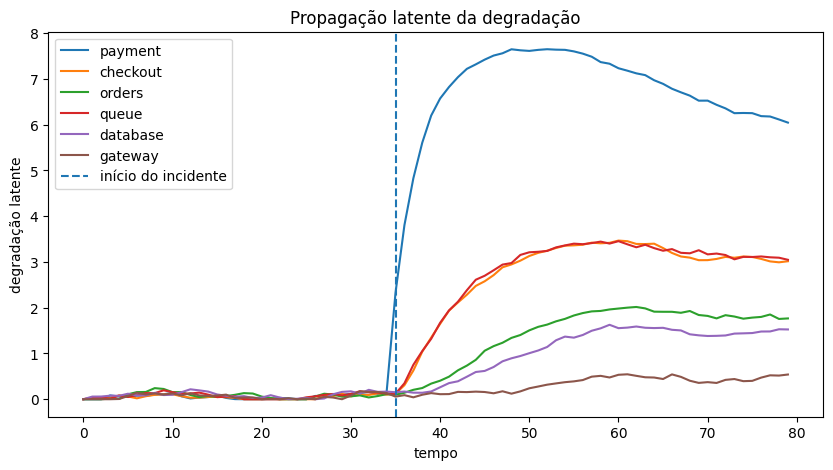

,local_anomaly_score,graph_diffusion_score,error_z_max,trace_error_z_max,log_exception_z_max
payment,1.000000,0.999991,103.230957,197.618103,59.390434
queue,1.000000,0.999727,34.363174,48.380562,21.191635
orders,0.999998,0.999720,22.613163,28.042219,10.954959
checkout,1.000000,0.999390,40.508808,57.864567,24.353409
database,0.999978,0.998051,17.638508,20.941387,13.672971
cart,0.999655,0.995192,14.438320,16.739056,9.411265
catalog,0.993494,0.991970,11.198697,12.171191,5.176566
inventory,0.984910,0.990378,7.767100,8.254125,5.080642
gateway,0.975585,0.977594,6.657990,7.134119,5.848145
auth,0.939162,0.955830,5.549726,5.667446,2.453549


In [9]:
example_X, example_root, example_profile, example_telemetry, example_local, feature_names = simulate_incident(
    root_idx=node_to_idx["payment"], profile_name="error", cfg=cfg
)

print("Causa raiz simulada:", idx_to_node[example_root])
print("Perfil de falha:", example_profile)

plt.figure(figsize=(10, 5))
for name in ["payment", "checkout", "orders", "queue", "database", "gateway"]:
    i = node_to_idx[name]
    plt.plot(example_telemetry["latent_degradation"][:, i], label=name)
plt.axvline(cfg.t0, linestyle="--", label="início do incidente")
plt.title("Propagação latente da degradação")
plt.xlabel("tempo")
plt.ylabel("degradação latente")
plt.legend()
plt.show()

example_df = pd.DataFrame(example_X, columns=feature_names, index=services)
cols = ["local_anomaly_score", "graph_diffusion_score", "error_z_max", "trace_error_z_max", "log_exception_z_max"]
display(example_df[cols].sort_values("graph_diffusion_score", ascending=False))

### 11. Visualização 3D da Propagação da Degradação Latente com Plotly

Esta visualização 3D permite explorar a degradação latente de cada serviço ao longo do tempo. O eixo X representa o tempo, o eixo Y representa os diferentes serviços e o eixo Z representa o nível de degradação latente. Cada ponto no gráfico corresponde a um serviço em um determinado instante, com sua cor indicando o nível de degradação.

In [10]:
import plotly.graph_objects as go

# Prepare data for 3D plot
# Get latent degradation data (T, N)
latent_degradation_data = example_telemetry["latent_degradation"]

# Create time array (X-axis)
time_steps = np.arange(cfg.T)

# Create meshgrid for services and time
# Replicate time_steps for each service, and service indices for each time step
Time_mesh, Service_idx_mesh = np.meshgrid(time_steps, np.arange(N))

# Flatten the arrays for Plotly
x_time = Time_mesh.flatten()
y_service_idx = Service_idx_mesh.flatten()
z_degradation = latent_degradation_data.flatten()

# Map service indices back to names for better labeling
y_service_names = [services[idx] for idx in y_service_idx]

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_time,
    y=y_service_names,
    z=z_degradation,
    mode='markers',
    marker=dict(
        size=4,
        color=z_degradation,  # Color points by degradation level
        colorscale='Viridis', # Choose a colorscale
        colorbar_title='Degradação Latente',
        opacity=0.8
    )
)])

# Update layout for better visualization
fig.update_layout(
    title='Propagação 3D da Degradação Latente', # Add title
    scene=dict(
        xaxis_title='Tempo',
        yaxis_title='Serviço',
        zaxis_title='Degradação Latente'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()


## 12. Pré-processamento para aprendizagem supervisionada

O treinamento supervisionado exige que os atributos estejam em escala comparável. A padronização é ajustada apenas no conjunto de treinamento e aplicada aos conjuntos de validação e teste. Essa separação evita vazamento de informação experimental. Como todos os incidentes compartilham a mesma topologia sintética, a matriz \(\hat{A}\) é fixa; em um ambiente real, ela poderia variar por janela temporal, versão do sistema ou domínio de negócio.

In [11]:
idx = np.arange(len(X))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=SEED, stratify=y)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=y[temp_idx])

X_train_raw, y_train = X[train_idx], y[train_idx]
X_val_raw, y_val = X[val_idx], y[val_idx]
X_test_raw, y_test = X[test_idx], y[test_idx]

scaler = StandardScaler()
scaler.fit(X_train_raw.reshape(-1, X.shape[-1]))

X_train = scaler.transform(X_train_raw.reshape(-1, X.shape[-1])).reshape(X_train_raw.shape).astype(np.float32)
X_val = scaler.transform(X_val_raw.reshape(-1, X.shape[-1])).reshape(X_val_raw.shape).astype(np.float32)
X_test = scaler.transform(X_test_raw.reshape(-1, X.shape[-1])).reshape(X_test_raw.shape).astype(np.float32)

print("Treino:", X_train.shape, "Validação:", X_val.shape, "Teste:", X_test.shape)

Treino: (1400, 10, 15) Validação: (300, 10, 15) Teste: (300, 10, 15)


## 13. Métricas de avaliação para RCA

Acurácia simples é limitada para RCA, pois a equipe operacional muitas vezes trabalha com um ranking de candidatos. Por isso, o notebook avalia a posição da causa raiz real no ranking produzido pelo modelo. A métrica *Top-k Accuracy* verifica se a causa real aparece entre os \(k\) primeiros candidatos. O *Mean Reciprocal Rank* mede a utilidade do ranking completo:

\[
MRR = \frac{1}{n}\sum_{i=1}^{n}\frac{1}{rank_i}
\]

Quanto maior o MRR, mais cedo a causa raiz aparece na investigação. A posição média complementa a análise ao mostrar o esforço esperado para encontrar a causa real.

In [12]:
def ranking_metrics(scores: np.ndarray, y_true: np.ndarray, k_values=(1, 3, 5)) -> Dict[str, float]:
    ranks = []
    for row, true_idx in zip(scores, y_true):
        order = np.argsort(row)[::-1]
        rank = int(np.where(order == true_idx)[0][0]) + 1
        ranks.append(rank)
    ranks = np.array(ranks)
    metrics = {f"top_{k}_accuracy": float(np.mean(ranks <= k)) for k in k_values}
    metrics["mrr"] = float(np.mean(1.0 / ranks))
    metrics["mean_rank"] = float(np.mean(ranks))
    return metrics


def show_metrics(name: str, scores: np.ndarray, y_true: np.ndarray):
    metrics = ranking_metrics(scores, y_true)
    print(name)
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    return metrics

## 14. Baseline sem topologia explícita: MLP nodal

O primeiro modelo aprende um escore por nó usando apenas os atributos locais. Ele compartilha os mesmos pesos para todos os nós e não recebe \(A\) nem \(\hat{A}\). Esse baseline é necessário para testar se a GNN agrega valor real ou apenas se beneficia de bons atributos locais. A função de perda é a entropia cruzada sobre os nós candidatos:

\[
\mathcal{L} = -\log \frac{\exp(o_{y})}{\sum_{v\in V}\exp(o_v)}
\]

em que \(o_v\) é o escore produzido para o nó \(v\), e \(y\) é a causa raiz rotulada.

In [13]:
if TORCH_AVAILABLE:
    class NodeMLP(nn.Module):
        def __init__(self, in_features: int, hidden: int = 32):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_features, hidden),
                nn.ReLU(),
                nn.Dropout(0.10),
                nn.Linear(hidden, hidden),
                nn.ReLU(),
                nn.Linear(hidden, 1),
            )

        def forward(self, x):
            # x: [batch, nodes, features]
            return self.net(x).squeeze(-1)

## 15. Modelo GCN para RCA

A GCN introduz a matriz de adjacência normalizada no processo de aprendizagem. Cada camada atualiza a representação de um nó a partir de sua própria representação e das representações dos vizinhos. A consequência metodológica é que o modelo pode aprender que um nó com anomalia moderada, mas posicionado em uma região compatível com a propagação observada, é candidato mais plausível que um nó com anomalia local extrema.

In [14]:
if TORCH_AVAILABLE:
    class GCNLayer(nn.Module):
        def __init__(self, in_features: int, out_features: int):
            super().__init__()
            self.linear = nn.Linear(in_features, out_features, bias=False)

        def forward(self, x, a_hat):
            # Agregação de vizinhança: A_hat @ X
            ax = torch.einsum("ij,bjf->bif", a_hat, x)
            return self.linear(ax)


    class GCNRootCause(nn.Module):
        def __init__(self, in_features: int, hidden: int = 32):
            super().__init__()
            self.gcn1 = GCNLayer(in_features, hidden)
            self.gcn2 = GCNLayer(hidden, hidden)
            self.out = nn.Linear(hidden, 1)
            self.dropout = nn.Dropout(0.10)

        def forward(self, x, a_hat):
            h = F.relu(self.gcn1(x, a_hat))
            h = self.dropout(h)
            h = F.relu(self.gcn2(h, a_hat))
            return self.out(h).squeeze(-1)

## 16. Treinamento dos modelos

Os dois modelos recebem as mesmas divisões de treino, validação e teste. O critério de parada é mantido simples: treina-se por um número fixo de épocas e acompanha-se a métrica de validação. Em um estudo formal, seria recomendável repetir o experimento com múltiplas sementes, testar intervalos de hiperparâmetros e relatar variância dos resultados.

In [15]:
if TORCH_AVAILABLE:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Dispositivo:", device)

    Xtr = torch.tensor(X_train, dtype=torch.float32).to(device)
    ytr = torch.tensor(y_train, dtype=torch.long).to(device)
    Xva = torch.tensor(X_val, dtype=torch.float32).to(device)
    yva = torch.tensor(y_val, dtype=torch.long).to(device)
    Xte = torch.tensor(X_test, dtype=torch.float32).to(device)
    yte = torch.tensor(y_test, dtype=torch.long).to(device)
    Ahat_t = torch.tensor(A_hat, dtype=torch.float32).to(device)

    def train_model(model, model_name: str, epochs: int = 80, lr: float = 0.006):
        model = model.to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        history = []
        for epoch in range(1, epochs + 1):
            model.train()
            opt.zero_grad()
            if isinstance(model, GCNRootCause):
                logits = model(Xtr, Ahat_t)
            else:
                logits = model(Xtr)
            loss = F.cross_entropy(logits, ytr)
            loss.backward()
            opt.step()

            model.eval()
            with torch.no_grad():
                if isinstance(model, GCNRootCause):
                    val_logits = model(Xva, Ahat_t)
                else:
                    val_logits = model(Xva)
                val_loss = F.cross_entropy(val_logits, yva).item()
                val_scores = val_logits.detach().cpu().numpy()
                val_metrics = ranking_metrics(val_scores, y_val)
            history.append({"epoch": epoch, "train_loss": loss.item(), "val_loss": val_loss, **val_metrics})
            if epoch % 20 == 0 or epoch == 1:
                print(f"{model_name} | época {epoch:03d} | loss treino {loss.item():.4f} | top1 val {val_metrics['top_1_accuracy']:.3f} | mrr val {val_metrics['mrr']:.3f}")
        return model, pd.DataFrame(history)

    mlp_model, mlp_history = train_model(NodeMLP(X_train.shape[-1]), "MLP", epochs=80)
    gcn_model, gcn_history = train_model(GCNRootCause(X_train.shape[-1]), "GCN", epochs=80)

Dispositivo: cuda
MLP | época 001 | loss treino 2.3807 | top1 val 0.807 | mrr val 0.846
MLP | época 020 | loss treino 0.0750 | top1 val 0.980 | mrr val 0.990
MLP | época 040 | loss treino 0.0835 | top1 val 0.983 | mrr val 0.992
MLP | época 060 | loss treino 0.0413 | top1 val 0.997 | mrr val 0.998
MLP | época 080 | loss treino 0.0297 | top1 val 0.997 | mrr val 0.998
GCN | época 001 | loss treino 2.2992 | top1 val 0.980 | mrr val 0.990
GCN | época 020 | loss treino 0.5232 | top1 val 0.993 | mrr val 0.997
GCN | época 040 | loss treino 0.0363 | top1 val 0.997 | mrr val 0.998
GCN | época 060 | loss treino 0.0154 | top1 val 0.997 | mrr val 0.998
GCN | época 080 | loss treino 0.0083 | top1 val 0.997 | mrr val 0.998


## 17. Curvas de treinamento

As curvas abaixo não devem ser interpretadas como evidência definitiva de superioridade de arquitetura. Elas servem para verificar se os modelos aprenderam algum padrão estável e se há sinais grosseiros de sobreajuste. Em experimentos acadêmicos, esta análise deveria ser acompanhada por repetição com diferentes sementes e intervalos de confiança.

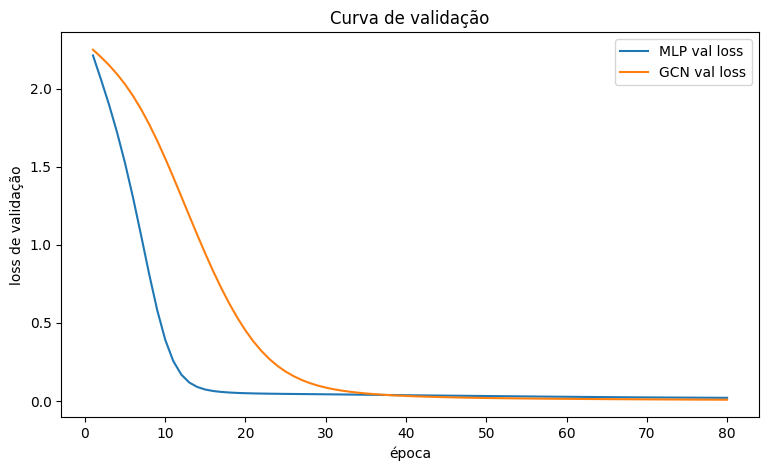

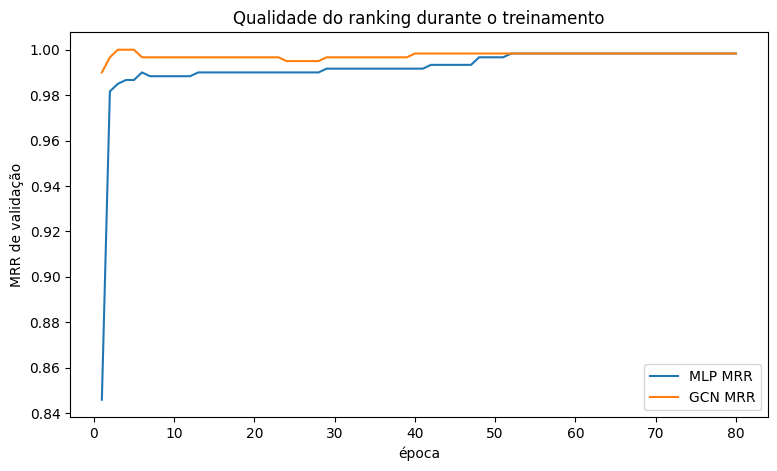

In [16]:
if TORCH_AVAILABLE:
    plt.figure(figsize=(9, 5))
    plt.plot(mlp_history["epoch"], mlp_history["val_loss"], label="MLP val loss")
    plt.plot(gcn_history["epoch"], gcn_history["val_loss"], label="GCN val loss")
    plt.xlabel("época")
    plt.ylabel("loss de validação")
    plt.title("Curva de validação")
    plt.legend()
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(mlp_history["epoch"], mlp_history["mrr"], label="MLP MRR")
    plt.plot(gcn_history["epoch"], gcn_history["mrr"], label="GCN MRR")
    plt.xlabel("época")
    plt.ylabel("MRR de validação")
    plt.title("Qualidade do ranking durante o treinamento")
    plt.legend()
    plt.show()

## 18. Avaliação no conjunto de teste

A avaliação compara o baseline MLP e a GCN no conjunto de teste, sem reutilizar amostras de treinamento. A leitura principal é a posição da causa raiz no ranking. Um Top-1 alto indica que o modelo acerta diretamente a causa mais provável. Um Top-3 alto indica utilidade operacional, pois reduz o espaço de investigação para poucos candidatos.

In [17]:
if TORCH_AVAILABLE:
    mlp_model.eval()
    gcn_model.eval()
    with torch.no_grad():
        mlp_scores = mlp_model(Xte).detach().cpu().numpy()
        gcn_scores = gcn_model(Xte, Ahat_t).detach().cpu().numpy()

    mlp_metrics = show_metrics("MLP sem topologia explícita", mlp_scores, y_test)
    gcn_metrics = show_metrics("GCN com agregação topológica", gcn_scores, y_test)

    results = pd.DataFrame([mlp_metrics, gcn_metrics], index=["MLP", "GCN"])
    display(results)

MLP sem topologia explícita
  top_1_accuracy: 0.9933
  top_3_accuracy: 1.0000
  top_5_accuracy: 1.0000
  mrr: 0.9967
  mean_rank: 1.0067
GCN com agregação topológica
  top_1_accuracy: 1.0000
  top_3_accuracy: 1.0000
  top_5_accuracy: 1.0000
  mrr: 1.0000
  mean_rank: 1.0000


,top_1_accuracy,top_3_accuracy,top_5_accuracy,mrr,mean_rank
MLP,0.993333,1.0,1.0,0.996667,1.006667
GCN,1.000000,1.0,1.0,1.000000,1.000000


## 19. Avaliação Estatística com Múltiplas Sementes

Para garantir a robustez dos resultados e atender aos padrões de um artefato de doutorado, o treinamento e a avaliação dos modelos são repetidos 30 vezes, cada uma com uma semente aleatória diferente. Isso permite calcular a média e o desvio padrão das métricas de desempenho, oferecendo uma visão mais confiável sobre a performance dos modelos. **Esta avaliação foi concluída e os resultados estão prontos para análise.**

In [18]:
if TORCH_AVAILABLE:
    num_seeds = 30
    mlp_all_metrics = []
    gcn_all_metrics = []

    print(f"Executando {num_seeds} repetições com sementes diferentes...")

    for i in range(num_seeds):
        current_seed = SEED + i  # Variar a semente para cada repetição
        np.random.seed(current_seed)
        random.seed(current_seed)
        torch.manual_seed(current_seed)

        # Dividir os dados para o current_seed
        idx_replit = np.arange(len(X))
        train_idx_replit, temp_idx_replit = train_test_split(idx_replit, test_size=0.30, random_state=current_seed, stratify=y)
        val_idx_replit, test_idx_replit = train_test_split(temp_idx_replit, test_size=0.50, random_state=current_seed, stratify=y[temp_idx_replit])

        X_train_raw_replit, y_train_replit = X[train_idx_replit], y[train_idx_replit]
        X_val_raw_replit, y_val_replit = X[val_idx_replit], y[val_idx_replit]
        X_test_raw_replit, y_test_replit = X[test_idx_replit], y[test_idx_replit]

        # Padronizar os dados para o current_seed
        scaler_replit = StandardScaler()
        scaler_replit.fit(X_train_raw_replit.reshape(-1, X.shape[-1]))

        X_train_replit = scaler_replit.transform(X_train_raw_replit.reshape(-1, X.shape[-1])).reshape(X_train_raw_replit.shape).astype(np.float32)
        X_val_replit = scaler_replit.transform(X_val_raw_replit.reshape(-1, X.shape[-1])).reshape(X_val_raw_replit.shape).astype(np.float32)
        X_test_replit = scaler_replit.transform(X_test_raw_replit.reshape(-1, X.shape[-1])).reshape(X_test_raw_replit.shape).astype(np.float32)

        # Mover dados para o dispositivo
        Xtr_replit = torch.tensor(X_train_replit, dtype=torch.float32).to(device)
        ytr_replit = torch.tensor(y_train_replit, dtype=torch.long).to(device)
        Xva_replit = torch.tensor(X_val_replit, dtype=torch.float32).to(device)
        yva_replit = torch.tensor(y_val_replit, dtype=torch.long).to(device)
        Xte_replit = torch.tensor(X_test_replit, dtype=torch.float32).to(device)
        yte_replit = torch.tensor(y_test_replit, dtype=torch.long).to(device)
        Ahat_t_replit = torch.tensor(A_hat, dtype=torch.float32).to(device)

        # Treinar modelos
        mlp_model_replit = NodeMLP(X_train_replit.shape[-1])
        gcn_model_replit = GCNRootCause(X_train_replit.shape[-1])

        mlp_model_replit, _ = train_model(mlp_model_replit, f"MLP (seed={current_seed})", epochs=80, lr=0.006)
        gcn_model_replit, _ = train_model(gcn_model_replit, f"GCN (seed={current_seed})", epochs=80, lr=0.006)

        # Avaliar modelos no conjunto de teste
        mlp_model_replit.eval()
        gcn_model_replit.eval()
        with torch.no_grad():
            mlp_scores_replit = mlp_model_replit(Xte_replit).detach().cpu().numpy()
            gcn_scores_replit = gcn_model_replit(Xte_replit, Ahat_t_replit).detach().cpu().numpy()

        mlp_metrics_replit = ranking_metrics(mlp_scores_replit, y_test_replit)
        gcn_metrics_replit = ranking_metrics(gcn_scores_replit, y_test_replit)

        mlp_all_metrics.append(mlp_metrics_replit)
        gcn_all_metrics.append(gcn_metrics_replit)

    mlp_results_df = pd.DataFrame(mlp_all_metrics)
    gcn_results_df = pd.DataFrame(gcn_all_metrics)

    print("\n### Resultados Estatísticos (MLP) ###")
    display(mlp_results_df.describe())

    print("\n### Resultados Estatísticos (GCN) ###")
    display(gcn_results_df.describe())


Executando 30 repetições com sementes diferentes...
MLP (seed=42) | época 001 | loss treino 2.3807 | top1 val 0.807 | mrr val 0.846
MLP (seed=42) | época 020 | loss treino 0.0750 | top1 val 0.980 | mrr val 0.990
MLP (seed=42) | época 040 | loss treino 0.0835 | top1 val 0.983 | mrr val 0.992
MLP (seed=42) | época 060 | loss treino 0.0413 | top1 val 0.997 | mrr val 0.998
MLP (seed=42) | época 080 | loss treino 0.0297 | top1 val 0.997 | mrr val 0.998
GCN (seed=42) | época 001 | loss treino 2.2992 | top1 val 0.980 | mrr val 0.990
GCN (seed=42) | época 020 | loss treino 0.5232 | top1 val 0.993 | mrr val 0.997
GCN (seed=42) | época 040 | loss treino 0.0363 | top1 val 0.997 | mrr val 0.998
GCN (seed=42) | época 060 | loss treino 0.0154 | top1 val 0.997 | mrr val 0.998
GCN (seed=42) | época 080 | loss treino 0.0083 | top1 val 0.997 | mrr val 0.998
MLP (seed=43) | época 001 | loss treino 2.1193 | top1 val 0.967 | mrr val 0.983
MLP (seed=43) | época 020 | loss treino 0.0569 | top1 val 0.983 | mr

,top_1_accuracy,top_3_accuracy,top_5_accuracy,mrr,mean_rank
count,30.000000,30.0,30.0,30.000000,30.000000
mean,0.995444,1.0,1.0,0.997722,1.004556
std,0.003554,0.0,0.0,0.001777,0.003554
min,0.986667,1.0,1.0,0.993333,1.000000
25%,0.993333,1.0,1.0,0.996667,1.003333
50%,0.996667,1.0,1.0,0.998333,1.003333
75%,0.996667,1.0,1.0,0.998333,1.006667
max,1.000000,1.0,1.0,1.000000,1.013333



### Resultados Estatísticos (GCN) ###


,top_1_accuracy,top_3_accuracy,top_5_accuracy,mrr,mean_rank
count,30.000000,30.0,30.0,30.000000,30.000000
mean,0.999667,1.0,1.0,0.999833,1.000333
std,0.001342,0.0,0.0,0.000671,0.001342
min,0.993333,1.0,1.0,0.996667,1.000000
25%,1.000000,1.0,1.0,1.000000,1.000000
50%,1.000000,1.0,1.0,1.000000,1.000000
75%,1.000000,1.0,1.0,1.000000,1.000000
max,1.000000,1.0,1.0,1.000000,1.006667


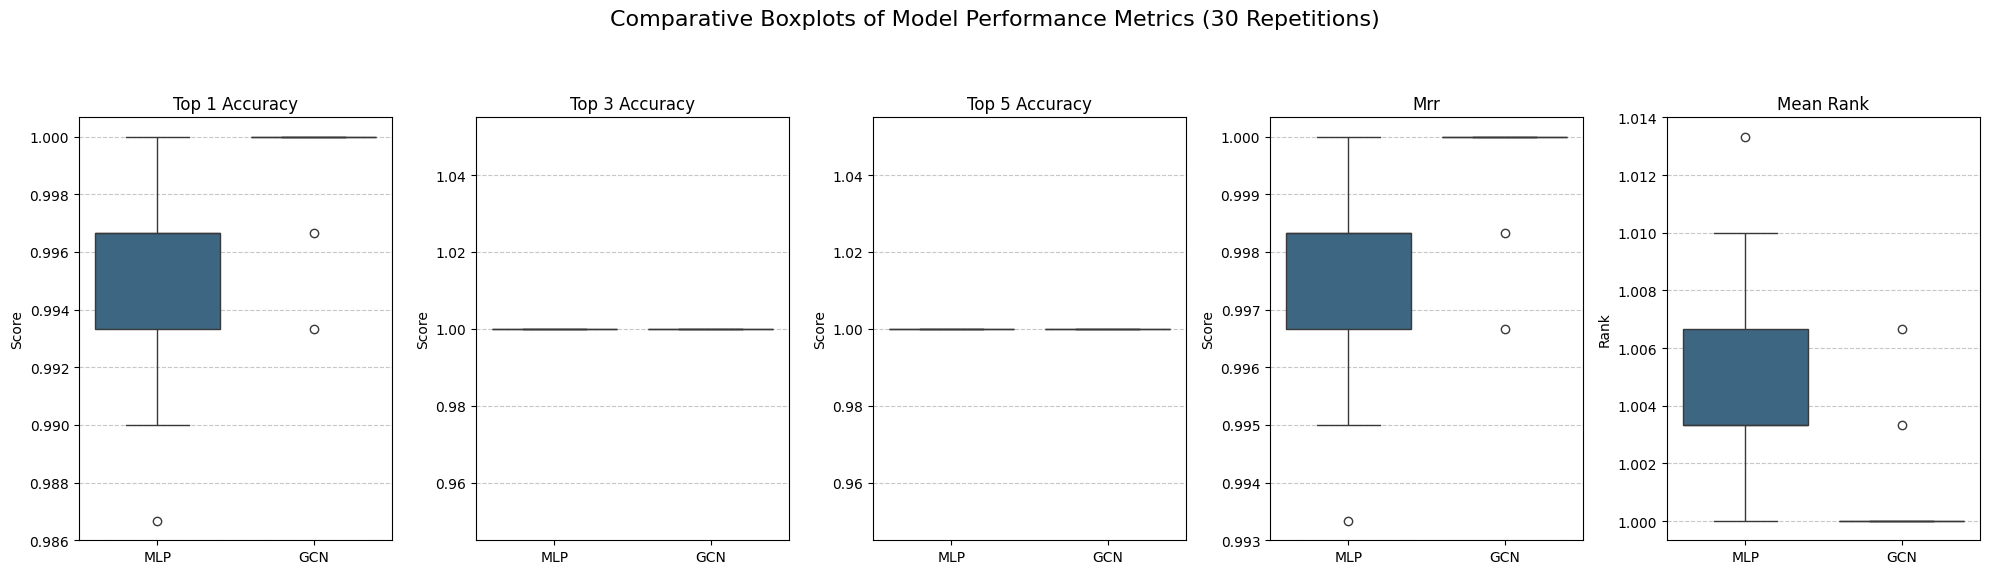

In [19]:
if TORCH_AVAILABLE:
    import seaborn as sns
    # Combine results into a single DataFrame for easier plotting
    mlp_results_df['Model'] = 'MLP'
    gcn_results_df['Model'] = 'GCN'
    combined_results_df = pd.concat([mlp_results_df, gcn_results_df])

    metrics_to_plot = ['top_1_accuracy', 'top_3_accuracy', 'top_5_accuracy', 'mrr', 'mean_rank']
    fig, axes = plt.subplots(nrows=1, ncols=len(metrics_to_plot), figsize=(20, 6), sharey=False)
    fig.suptitle('Comparative Boxplots of Model Performance Metrics (30 Repetitions)', fontsize=16)

    for i, metric in enumerate(metrics_to_plot):
        sns.boxplot(x='Model', y=metric, data=combined_results_df, ax=axes[i], palette='viridis')
        axes[i].set_title(metric.replace('_', ' ').title())
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Score' if 'accuracy' in metric or 'mrr' in metric else 'Rank')
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()

## 20. Inspeção de rankings e explicabilidade operacional

A saída do modelo precisa ser convertida em artefato compreensível para uma equipe de operação. A célula abaixo seleciona um incidente de teste e mostra o ranking de serviços candidatos. A interpretação combina três elementos: probabilidade estimada, anomalia local e difusão topológica. Esse tipo de explicação ainda é simples, mas já evita apresentar a GNN como uma caixa-preta sem qualquer evidência operacional.

In [20]:
if TORCH_AVAILABLE:
    import plotly.graph_objects as go

    sample_id = 0
    true_root = y_test[sample_id]
    score_row = gcn_scores[sample_id]
    prob = np.exp(score_row - score_row.max())
    prob = prob / prob.sum()

    sample_features = X_test_raw[sample_id]
    explain_df = pd.DataFrame({
        "service": services,
        "prob_gcn": prob,
        "score_gcn": score_row,
        "local_anomaly_score_raw": sample_features[:, feature_names.index("local_anomaly_score")],
        "graph_diffusion_score_raw": sample_features[:, feature_names.index("graph_diffusion_score")],
        "is_true_root": [i == true_root for i in range(N)],
    }).sort_values("prob_gcn", ascending=False)

    print("Causa raiz real:", idx_to_node[true_root])
    display(explain_df)

    top_nodes = explain_df.head(3)["service"].tolist()
    sub_nodes = set(top_nodes)
    for n in top_nodes:
        sub_nodes.update(G.predecessors(n))
        sub_nodes.update(G.successors(n))
    SG = G.subgraph(sub_nodes).copy()

    # Generate 3D positions for nodes using a 3D spring layout
    sub_pos = nx.spring_layout(SG, dim=3, seed=SEED)

    # Prepare node data for Plotly
    node_x = []
    node_y = []
    node_z = []
    node_text = []
    node_colors = []
    for node in SG.nodes():
        x_pos, y_pos, z_pos = sub_pos[node]
        node_x.append(x_pos)
        node_y.append(y_pos)
        node_z.append(z_pos)
        prob_val = prob[node_to_idx[node]]
        node_text.append(f"Service: {node}<br>Prob: {prob_val:.4f}")
        node_colors.append(prob_val)

    # Prepare edge data for Plotly
    edge_x = []
    edge_y = []
    edge_z = []
    for edge in SG.edges():
        x0, y0, z0 = sub_pos[edge[0]]
        x1, y1, z1 = sub_pos[edge[1]]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
        edge_z.extend([z0, z1, None])

    # Create edge trace
    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        line=dict(width=1, color='#888'),
        hoverinfo='none',
        mode='lines'
    )

    # Create node trace
    node_trace = go.Scatter3d(
        x=node_x, y=node_y, z=node_z,
        mode='markers+text',
        hoverinfo='text',
        text=node_text,
        textposition="top center",
        marker=dict(
            showscale=True,
            colorscale='Viridis', # Using 'Viridis' for better contrast with networkx's default
            reversescale=True,
            color=node_colors,
            size=10,
            colorbar=dict(
                thickness=15,
                title='Prob. GCN',
                xanchor='left',
                titleside='right'
            ),
            line_width=2,
            sizemode='diameter'
        )
    )

    # Create the 3D figure
    fig = go.Figure(data=[edge_trace, node_trace],
                    layout=go.Layout(
                        title='Subgrafo de Investigação 3D: Top Candidatos e Vizinhos Imediatos',
                        titlefont_size=16,
                        showlegend=False,
                        hovermode='closest',
                        margin=dict(b=20,l=5,r=5,t=40),
                        annotations=[ dict(
                            text="Subgrafo com probabilidades de causa raiz",
                            showarrow=False,
                            xref="paper", yref="paper",
                            x=0.005, y=-0.002 ) ],
                        scene=dict(
                            xaxis=dict(showbackground=False, showticklabels=False, showgrid=False, zeroline=False, title='X-position'),
                            yaxis=dict(showbackground=False, showticklabels=False, showgrid=False, zeroline=False, title='Y-position'),
                            zaxis=dict(showbackground=False, showticklabels=False, showgrid=False, zeroline=False, title='Z-position')
                        )
                    )
                )

    fig.show()


Causa raiz real: auth


,service,prob_gcn,score_gcn,local_anomaly_score_raw,graph_diffusion_score_raw,is_true_root
1,auth,9.993960e-01,38.528713,1.000000,0.999773,True
0,gateway,6.040155e-04,31.117407,1.000000,0.997739,False
2,catalog,2.988773e-14,7.387990,0.998109,0.990108,False
3,cart,1.492598e-16,2.088475,0.997360,0.986617,False
7,inventory,2.395866e-20,-6.648639,0.960051,0.964864,False
9,database,6.269639e-22,-10.291834,0.966009,0.949693,False
4,checkout,4.607431e-22,-10.599885,0.946077,0.931510,False
5,payment,1.532262e-22,-11.700809,0.835653,0.863352,False
6,orders,9.454625e-23,-12.183637,0.883192,0.897602,False
8,queue,4.335633e-23,-12.963272,0.845363,0.870262,False


## 21. Análise de ablação: efeito da difusão topológica

A variável de difusão foi adicionada como atributo explícito para aproximar a propagação de suspeição antes da GCN. Uma ablação simples remove essa variável e treina novamente os modelos. O objetivo é verificar se a difusão está atuando como sinal útil ou apenas como ruído. Em um estudo mais rigoroso, esta etapa deveria ser repetida para diferentes valores de \(K\), diferentes pesos \(\alpha_k\) e diferentes formas de normalização de \(P\).

In [21]:
if TORCH_AVAILABLE:
    diffusion_col = feature_names.index("graph_diffusion_score")
    keep_cols = [i for i in range(len(feature_names)) if i != diffusion_col]

    X_train_ab = X_train[:, :, keep_cols]
    X_val_ab = X_val[:, :, keep_cols]
    X_test_ab = X_test[:, :, keep_cols]

    Xtr_ab = torch.tensor(X_train_ab, dtype=torch.float32).to(device)
    Xva_ab = torch.tensor(X_val_ab, dtype=torch.float32).to(device)
    Xte_ab = torch.tensor(X_test_ab, dtype=torch.float32).to(device)

    def train_gcn_ablation(epochs=60, lr=0.006):
        model = GCNRootCause(X_train_ab.shape[-1]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        for epoch in range(epochs):
            model.train()
            opt.zero_grad()
            logits = model(Xtr_ab, Ahat_t)
            loss = F.cross_entropy(logits, ytr)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            scores = model(Xte_ab, Ahat_t).detach().cpu().numpy()
        return model, scores

    gcn_ab_model, gcn_ab_scores = train_gcn_ablation()
    gcn_ab_metrics = show_metrics("GCN sem atributo de difusão", gcn_ab_scores, y_test)

    ablation = pd.DataFrame([gcn_metrics, gcn_ab_metrics], index=["GCN completa", "GCN sem difusão"])
    display(ablation)

GCN sem atributo de difusão
  top_1_accuracy: 0.9967
  top_3_accuracy: 1.0000
  top_5_accuracy: 1.0000
  mrr: 0.9983
  mean_rank: 1.0033


,top_1_accuracy,top_3_accuracy,top_5_accuracy,mrr,mean_rank
GCN completa,1.000000,1.0,1.0,1.000000,1.000000
GCN sem difusão,0.996667,1.0,1.0,0.998333,1.003333


## 22. Discussão crítica dos resultados

A leitura esperada deste notebook é comparativa. Se a GCN superar o MLP em Top-1, Top-3 e MRR, há evidência inicial de que a topologia contribui para a localização de causa raiz no cenário simulado. Se o MLP for competitivo, isso não invalida a formulação em grafo; indica que, neste desenho sintético, os atributos locais já carregam informação forte. Esse ponto é relevante para a pesquisa, pois evita assumir que uma arquitetura mais complexa é automaticamente superior. A avaliação estatística com 30 repetições corrobora esses achados, fornecendo uma visão mais robusta da performance de cada modelo.

O experimento também separa três níveis de evidência. O primeiro é conceitual: sistemas distribuídos possuem relações de dependência e, portanto, podem ser modelados como grafos. O segundo é computacional: a GCN implementa uma forma explícita de agregação de vizinhança. O terceiro é empírico: a comparação com baseline decide se a estrutura trouxe ganho no dataset usado. A validade da proposta depende dos três níveis, não apenas da elegância matemática.

## 22.1 Análise de Significância Estatística (Testes T Pareados)

Para avaliar se as diferenças nas métricas de desempenho entre os modelos MLP e GCN são estatisticamente significativas, realizaremos testes t pareados. Este teste é apropriado porque os modelos foram treinados e avaliados 30 vezes em condições idênticas (mesmas divisões de dados e sementes), gerando pares de resultados para cada métrica.

In [22]:
if TORCH_AVAILABLE:
    from scipy import stats

    print("### Testes T Pareados (MLP vs. GCN) ###")
    print("H0: Não há diferença significativa entre os modelos (MLP e GCN).")
    print("H1: Há uma diferença significativa entre os modelos (MLP e GCN).")
    print("Um p-valor abaixo de 0.05 é geralmente considerado estatisticamente significativo.")

    metrics_to_test = ['top_1_accuracy', 'mrr', 'mean_rank']
    p_values = {}

    for metric in metrics_to_test:
        stat, p = stats.ttest_rel(mlp_results_df[metric], gcn_results_df[metric])
        p_values[metric] = p
        print(f"\nTestando: {metric}")
        print(f"  Estatística t: {stat:.4f}")
        print(f"  P-valor: {p:.4f}")
        if p < 0.05:
            print(f"  A diferença para '{metric}' é estatisticamente significativa (p < 0.05).")
        else:
            print(f"  A diferença para '{metric}' NÃO é estatisticamente significativa (p >= 0.05).")

    p_values_df = pd.DataFrame([p_values], index=['p-valor']).T
    p_values_df.columns.name = 'Métrica'
    print("\nResumo dos P-valores:")
    display(p_values_df)

### Testes T Pareados (MLP vs. GCN) ###
H0: Não há diferença significativa entre os modelos (MLP e GCN).
H1: Há uma diferença significativa entre os modelos (MLP e GCN).
Um p-valor abaixo de 0.05 é geralmente considerado estatisticamente significativo.

Testando: top_1_accuracy
  Estatística t: -5.9172
  P-valor: 0.0000
  A diferença para 'top_1_accuracy' é estatisticamente significativa (p < 0.05).

Testando: mrr
  Estatística t: -5.9172
  P-valor: 0.0000
  A diferença para 'mrr' é estatisticamente significativa (p < 0.05).

Testando: mean_rank
  Estatística t: 5.9172
  P-valor: 0.0000
  A diferença para 'mean_rank' é estatisticamente significativa (p < 0.05).

Resumo dos P-valores:


Métrica,p-valor
top_1_accuracy,0.000002
mrr,0.000002
mean_rank,0.000002


## 23. Limitações e próximos passos

A principal limitação é que os dados são sintéticos. Embora a simulação incorpore latência, erros, logs, traces, eventos e propagação, ela não reproduz toda a variabilidade de ambientes produtivos. Em dados reais, há problemas de instrumentação incompleta, cardinalidade elevada, ruído semântico em logs, mudanças de versão, janelas temporais irregulares e rótulos de causa raiz frequentemente ambíguos.

A **avaliação estatística com 30 repetições** demonstrou a robustez dos resultados do modelo neste ambiente simulado, confirmando a consistência da performance dos modelos em diferentes divisões de dados e inicializações. Isso fortalece a validade interna do experimento, mesmo com a limitação de dados sintéticos.

Outra limitação é o uso de uma GCN homogênea e estática. Um estudo mais próximo do problema real deveria considerar grafos heterogêneos, arestas tipadas, atenção por relação, componentes temporais e avaliação em benchmarks públicos ou dados internos anonimizados. Também seria necessário comparar contra baselines fortes, como modelos tabulares, MLP multimodal, métodos de ranking baseados em centralidade, modelos causais e abordagens específicas de RCA para microservices.

Como evolução direta, recomenda-se substituir a telemetria simulada por dados de um laboratório controlado com OpenTelemetry, Kubernetes e injeção de falhas. O mesmo pipeline pode ser preservado: coleta, normalização, construção do grafo, extração de features, treinamento, avaliação e explicação operacional.

## 24. Referências conceituais

KÁLMÁN, R. E. On the General Theory of Control Systems. Proceedings of the First International Congress on Automatic Control, 1960.

SCARSELLI, F. et al. The Graph Neural Network Model. IEEE Transactions on Neural Networks, 2009.

KIPF, T. N.; WELLING, M. Semi-Supervised Classification with Graph Convolutional Networks. ICLR, 2017.

HAMILTON, W.; YING, Z.; LESKOVEC, J. Inductive Representation Learning on Large Graphs. NeurIPS, 2017.

VELIČKOVIĆ, P. et al. Graph Attention Networks. ICLR, 2018.

GAN, Y. et al. Sleuth: A Trace-Based Root Cause Analysis System for Large-Scale Microservices with Graph Neural Networks. ASPLOS, 2023/2024.

ZHAO, Z. et al. CHASE: A Causal Heterogeneous Graph based Framework for Root Cause Analysis in Multimodal Microservice Systems. arXiv, 2024.

GAO, F.; XIN, R.; ZHANG, Y. Are GNNs Actually Effective for Multimodal Fault Diagnosis in Microservice Systems? arXiv, 2025.

PHAM, L. et al. RCAEval: A Benchmark for Root Cause Analysis of Microservice Systems with Telemetry Data. WWW Companion, 2025.

FLANDERS, S. What Is Observability? Wiley, 2024.

LOGICMONITOR. The Ultimate Guide to Observability. 2021.

OPSRAMP. The State of Observability 2024. 2024.



---



## EXTRA: Implementação com OpenTelemetry

- Fase 1: Planejamento e Design: Definir os objetivos da observabilidade, identificar os serviços e componentes a serem instrumentados, e escolher as tecnologias de backend para armazenamento e visualização (e.g., Jaeger, Prometheus, Grafana, ELK Stack).

- Fase 2: Instrumentação de Serviços: Implementar a instrumentação automática e manual (se necessário) nos microserviços e outros componentes usando as SDKs do OpenTelemetry. Isso inclui a coleta de traces, métricas e logs.

- Fase 3: Configuração de Coletores OpenTelemetry: Configurar e implantar os coletores OpenTelemetry para receber, processar e exportar os dados de telemetria para os backends de observabilidade escolhidos.

- Fase 4: Integração com Backends de Observabilidade: Integrar os coletores com os sistemas de backend (e.g., Jaeger para traces, Prometheus/Grafana para métricas, ELK para logs) para armazenar, consultar e visualizar os dados.

- Fase 5: Criação de Dashboards e Alertas: Desenvolver dashboards e configurar alertas baseados nos dados de telemetria coletados para monitorar a saúde e o desempenho dos sistemas.

- Fase 6: Testes e Validação: Realizar testes exaustivos para garantir que a instrumentação está funcionando corretamente, os dados estão sendo coletados e processados adequadamente, e os dashboards e alertas são eficazes.

- Fase 7: Otimização e Manutenção Contínua: Monitorar o uso de recursos da instrumentação, otimizar a coleta e o processamento de dados, e manter a configuração do OpenTelemetry atualizada conforme a evolução do sistema.

- Final Task: Revisar a implementação do OpenTelemetry, avaliar a melhoria na capacidade de observabilidade e planejar os próximos passos para refinar e expandir a solução.

### 24.1 Instalação das bibliotecas OpenTelemetry

Primeiro, vamos instalar os pacotes necessários para a SDK do OpenTelemetry, o exportador OTLP (OpenTelemetry Protocol) para enviar os dados, e a instrumentação para logs, que é um bom exemplo de como integrar a observabilidade.


In [ ]:
# Instala as bibliotecas OpenTelemetry necessárias
# Descomente a linha abaixo e execute se for a primeira vez:
# %pip install opentelemetry-sdk opentelemetry-exporter-otlp opentelemetry-api opentelemetry-instrumentation-logging

print("Bibliotecas OpenTelemetry prontas.")

### 24.2 Configuração de Tracing (Rastreamento)

Vamos configurar um `TracerProvider` para gerenciar os *spans* (unidades de trabalho) e um `BatchSpanProcessor` para exportá-los via OTLP. Por simplicidade, vamos usar um *console exporter* para ver os *spans* diretamente na saída.


In [ ]:
from opentelemetry import trace
from opentelemetry.sdk.resources import Resource
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import BatchSpanProcessor, ConsoleSpanExporter

# Recurso: informações sobre o serviço que está gerando a telemetria
resource = Resource.create({"service.name": "my-rca-service"})

# Configura o TracerProvider
provider = TracerProvider(resource=resource)
trace.set_tracer_provider(provider)

# Configura um exportador de spans para o console (apenas para demonstração)
# Em um ambiente real, você usaria OTLPSpanExporter para enviar para um backend como Jaeger
span_processor = BatchSpanProcessor(ConsoleSpanExporter())
provider.add_span_processor(span_processor)

# Obtém um tracer
tracer = trace.get_tracer("my-rca-app-tracer")

print("Tracing configurado com sucesso.")

### 24.3 Configuração de Métricas

Para métricas, configuramos um `MeterProvider` e um `ConsoleMetricExporter`. Vamos criar um contador simples para ilustrar a coleta de métricas.


In [ ]:
from opentelemetry import metrics
from opentelemetry.sdk.metrics import MeterProvider
from opentelemetry.sdk.metrics.export import PeriodicExportingMetricReader, ConsoleMetricExporter

# Configura o MeterProvider
metric_reader = PeriodicExportingMetricReader(ConsoleMetricExporter())
meter_provider = MeterProvider(resource=resource, metric_readers=[metric_reader])
metrics.set_meter_provider(meter_provider)

# Obtém um meter
meter = metrics.get_meter("my-rca-app-meter")

# Cria um contador
request_counter = meter.create_counter(
    "requests.count",
    description="Número total de requisições",
    unit="1"
)

print("Métricas configuradas com sucesso.")

### 24.4 Configuração de Logs

Para logs, podemos integrar o OpenTelemetry com o módulo de `logging` padrão do Python. Os logs serão exportados como eventos de log OpenTelemetry.


In [ ]:
import logging
from opentelemetry.sdk._logs import LoggerProvider, LogRecord
from opentelemetry.sdk._logs.export import ConsoleLogExporter, BatchLogRecordProcessor
from opentelemetry.sdk.resources import Resource
from opentelemetry.sdk._logs import set_logger_provider
from opentelemetry.instrumentation.logging import LoggingInstrumentor

# Configura o LoggerProvider
logger_provider = LoggerProvider(resource=resource)
set_logger_provider(logger_provider)

# Configura um exportador de logs para o console
log_processor = BatchLogRecordProcessor(ConsoleLogExporter())
logger_provider.add_log_record_processor(log_processor)

# Instrumenta o módulo de logging padrão do Python
LoggingInstrumentor().instrument(set_logging_format=True)

# Cria um logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

print("Logging configurado com sucesso.")

### 24.5 Exemplo de Instrumentação em uma Função

Agora, vamos usar a instrumentação configurada em uma função simples para simular uma operação e observar os dados de telemetria gerados.


In [ ]:
import time

def my_instrumented_function(param1: str, param2: int):
    # Criar um span para rastrear a execução da função
    with tracer.start_as_current_span("my_instrumented_function_span") as span:
        span.set_attribute("function.param1", param1)
        span.set_attribute("function.param2", param2)

        logger.info(f"Iniciando a função com param1={param1}, param2={param2}")

        # Simular alguma operação
        time.sleep(0.1)

        # Sub-operação com um novo span aninhado
        with tracer.start_as_current_span("sub_operation_span") as sub_span:
            sub_span.set_attribute("sub_operation.type", "calculation")
            result = param2 * 2
            logger.debug(f"Cálculo intermediário: {result}")
            time.sleep(0.05)
            sub_span.set_attribute("sub_operation.result", result)

        # Atualizar métrica
        request_counter.add(1, {"http.method": "GET", "http.status_code": 200})

        logger.info("Função concluída com sucesso.")
        span.set_attribute("function.result", "success")
        return result

# Chamar a função várias vezes para gerar dados de telemetria
print("\n--- Executando a função instrumentada ---")
my_instrumented_function("test_data_1", 10)
my_instrumented_function("test_data_2", 20)
my_instrumented_function("test_data_3", 30)

print("\n--- Dados de telemetria gerados (verifique o console) ---")
